# 03 — Final Model Comparison (Test Set)

This is the **only** notebook that touches the test set, and it touches it
exactly once. Every model is refit on train+validation using the
hyperparameters chosen in `02_evaluation_setup.ipynb` (no new tuning
happens here), then evaluated on the held-out test interactions.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D
from src import evaluation as E
from src import pipeline as P

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
FIG_DIR = "../reports/figures"
TABLE_DIR = "../reports/tables"
K = P.K
print("Hyperparameters selected on validation (src/pipeline.py):")
P.BEST_PARAMS

Hyperparameters selected on validation (src/pipeline.py):


{'content_min_rating': 4,
 'als_factors': 32,
 'als_regularization': 0.01,
 'als_iterations': 20,
 'bpr_factors': 128,
 'bpr_iterations': 100,
 'hybrid_partner': 'Item-kNN',
 'hybrid_alpha': 0.1}

## 1. Refit on train+validation, evaluate once on test

In [2]:
users, movies, df, user_id_to_idx, item_id_to_idx = P.load_and_split("../data")
n_users = df["user_idx"].nunique()

fitted = P.fit_all_models(df, movies, item_id_to_idx, ["train", "val"])
seen_test = D.get_seen(df, ["train", "val"])
truth_test = D.get_truth(df, "test", threshold=D.RELEVANT_RATING_THRESHOLD)
users_test = list(truth_test.keys())

print(f"Candidate catalog (train+val): {len(fitted['catalog_items'])} movies")
print(f"Test evaluation cohort: {len(users_test)} / {n_users} users ({len(users_test)/n_users:.1%})")

Candidate catalog (train+val): 3677 movies
Test evaluation cohort: 5914 / 6040 users (97.9%)


In [3]:
rec_test = P.recommend_all(fitted, users_test, seen_test, K)
rows_test = P.evaluate_all(rec_test, truth_test, fitted, K)
test_metrics = pd.DataFrame(rows_test).set_index("model")
test_metrics.to_csv(f"{TABLE_DIR}/test_metrics.csv")
test_metrics.round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K,n_users,Coverage@K,Novelty@K,Diversity@K,AvgPopularity@K
model,,,,,,,,,
Popularity,0.0477,0.0623,0.0349,0.0739,5914,0.0362,8.4986,0.6451,2378.5814
Item-kNN,0.0819,0.0795,0.0514,0.1042,5914,0.1270,8.9366,0.6346,1846.6839
Content-Based,0.0169,0.0130,0.0069,0.0170,5914,0.8325,13.1368,0.0851,258.7722
ALS,0.0813,0.0684,0.0432,0.0907,5914,0.3555,9.6677,0.6020,1236.9680
BPR,0.0642,0.0480,0.0304,0.0664,5914,0.7623,11.1354,0.4841,618.7731
Hybrid,0.0830,0.0785,0.0500,0.1026,5914,0.1441,9.0434,0.5809,1733.8412


## 2. Final test results

*(Recall / Precision / MAP / NDCG at K=10; relevant = rating ≥ 4; every model
ranks the same train+val-observed catalog and has already-seen items removed.)*

In [4]:
main_cols = ["Recall@K", "Precision@K", "MAP@K", "NDCG@K"]
test_metrics[main_cols].sort_values("NDCG@K", ascending=False).round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K
model,,,,
Item-kNN,0.0819,0.0795,0.0514,0.1042
Hybrid,0.0830,0.0785,0.0500,0.1026
ALS,0.0813,0.0684,0.0432,0.0907
Popularity,0.0477,0.0623,0.0349,0.0739
BPR,0.0642,0.0480,0.0304,0.0664
Content-Based,0.0169,0.0130,0.0069,0.0170


**Reading the table:**

- **Item-kNN and the Hybrid model are effectively tied for best ranking quality** (NDCG@10 ≈ 0.104 / 0.103), with the Hybrid slightly ahead on Recall@10 (0.083 vs 0.082).
- **ALS**, after fixing the orientation bug found in `02_evaluation_setup.ipynb`, is a close third (NDCG@10 ≈ 0.091) — a legitimate, competitive collaborative model, not a broken one.
- **Popularity** is a real, non-trivial baseline (NDCG@10 ≈ 0.074) — it beats BPR and is not far behind ALS — but is beaten by every genuinely personalized model here. Unlike the *previous* version of this project, popularity is now in the same comparison, so this claim can actually be made and checked.
- **BPR** (the LightFM substitute, see `02`) is the weakest collaborative model on this data, weaker even than the non-personalized popularity baseline.
- **Content-based** is the weakest model overall on ranking accuracy — genre similarity alone is a poor predictor of which specific movie a user will rate highly next. Its value shows up on the beyond-accuracy metrics below, not here.

## 3. Beyond-accuracy metrics: coverage, novelty, diversity, popularity bias

In [5]:
beyond_cols = ["Coverage@K", "Novelty@K", "Diversity@K", "AvgPopularity@K"]
test_metrics[beyond_cols].round(4)

,Coverage@K,Novelty@K,Diversity@K,AvgPopularity@K
model,,,,
Popularity,0.0362,8.4986,0.6451,2378.5814
Item-kNN,0.1270,8.9366,0.6346,1846.6839
Content-Based,0.8325,13.1368,0.0851,258.7722
ALS,0.3555,9.6677,0.6020,1236.9680
BPR,0.7623,11.1354,0.4841,618.7731
Hybrid,0.1441,9.0434,0.5809,1733.8412


- **Coverage@10** — Content-Based reaches **83%** of the catalog across users; Popularity reaches **4%**. The personalized collaborative models (Item-kNN, ALS, Hybrid) sit in between (12–36%): they are far less repetitive than a pure popularity list, but still concentrate on a fraction of the catalog.
- **Novelty@10** — Content-Based recommends the least popular items on average (highest novelty); Popularity, by construction, recommends the most popular (lowest novelty).
- **Diversity@10 (within one user's list)** — Content-Based is the *lowest* here (0.085) despite having the *highest* catalog coverage. This is not a contradiction: content-based reaches into many different corners of the catalog **across different users**, but for any single user it returns a genre-homogeneous cluster (everything similar to what they already rated highly) — high coverage, low per-list diversity. Popularity has the opposite profile: the same fixed list for everyone (near-zero coverage) that happens to span many genres (high per-list diversity), because the most popular movies in aggregate are not all one genre.
- **AvgPopularity@10** — a literal popularity-bias number: Popularity recommends movies with ~2,400 average training interactions; Content-Based ~260; the collaborative and hybrid models fall in between.

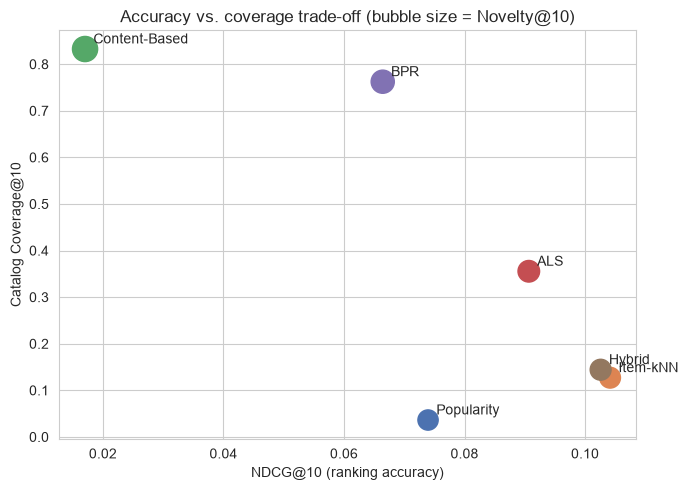

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette("deep", n_colors=len(test_metrics))
sc = ax.scatter(test_metrics["NDCG@K"], test_metrics["Coverage@K"],
                 s=test_metrics["Novelty@K"] * 25, c=colors)
for name, row in test_metrics.iterrows():
    ax.annotate(name, (row["NDCG@K"], row["Coverage@K"]), xytext=(6, 4), textcoords="offset points")
ax.set_xlabel("NDCG@10 (ranking accuracy)")
ax.set_ylabel("Catalog Coverage@10")
ax.set_title("Accuracy vs. coverage trade-off (bubble size = Novelty@10)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/accuracy_vs_coverage_tradeoff.png", dpi=150)
plt.show()

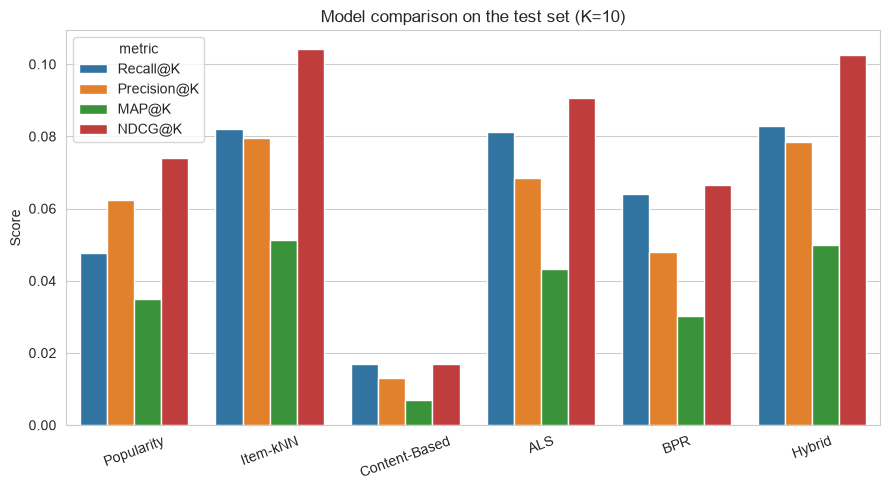

In [7]:
plot_df = test_metrics[main_cols].reset_index().melt(id_vars="model", var_name="metric", value_name="value")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="model", y="value", hue="metric")
plt.title("Model comparison on the test set (K=10)")
plt.ylabel("Score"); plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_comparison.png", dpi=150)
plt.show()

## 4. Sanity check: does the relevance threshold choice change the ranking of models?

`01_data_and_eda.ipynb` picked `rating >= 4` as the relevance threshold and
argued `rating >= 3` was too lenient. As a robustness check (not a
re-selection — hyperparameters are not re-tuned here), the same fitted
models are re-scored against a `rating >= 3` test truth to see whether the
*relative order* of models changes.

In [8]:
truth_test_r3 = D.get_truth(df, "test", threshold=3)
users_test_r3 = list(truth_test_r3.keys())
rec_test_r3 = P.recommend_all(fitted, users_test_r3, seen_test, K)
rows_r3 = P.evaluate_all(rec_test_r3, truth_test_r3, fitted, K)
pd.DataFrame(rows_r3).set_index("model")[main_cols].sort_values("NDCG@K", ascending=False).round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K
model,,,,
Item-kNN,0.0719,0.0986,0.0588,0.1186
Hybrid,0.0733,0.0975,0.0572,0.1169
ALS,0.0735,0.0862,0.0495,0.1042
Popularity,0.0410,0.0743,0.0402,0.0839
BPR,0.0610,0.0645,0.0358,0.0801
Content-Based,0.0163,0.0196,0.0086,0.0226


The ranking of models is the same under both thresholds (Item-kNN ≳ Hybrid >
ALS > Popularity > BPR > Content-Based on NDCG@10) — the relevance
threshold changes the absolute numbers (a looser threshold makes every
model look better, since more items count as "hits") but not which model
wins, so the main conclusions are not an artifact of the `>= 4` choice.